✅ Berhasil membaca file 'Data_Logistik_Indo.csv'

[Preview Data 5 Baris Teratas]
       Wilayah  Berat_Kg  Biaya_Kirim Status_Sampai
0  Jabodetabek       1.2      15000.0   Tepat Waktu
1    Luar Jawa       3.5      54000.0         Telat
2   Jawa Barat       0.8      12500.0   Tepat Waktu
3  Jabodetabek       5.0          NaN   Tepat Waktu
4    Luar Jawa      12.4     120000.0         Telat

✅ Model Decision Tree berhasil dilatih!

Akurasi Model: 100.00%

[Tabel Hasil Prediksi Data Test]
Kenyataan       | Prediksi Mesin
-----------------------------------
Telat           | Telat ✅
Tepat Waktu     | Tepat Waktu ✅
Tepat Waktu     | Tepat Waktu ✅


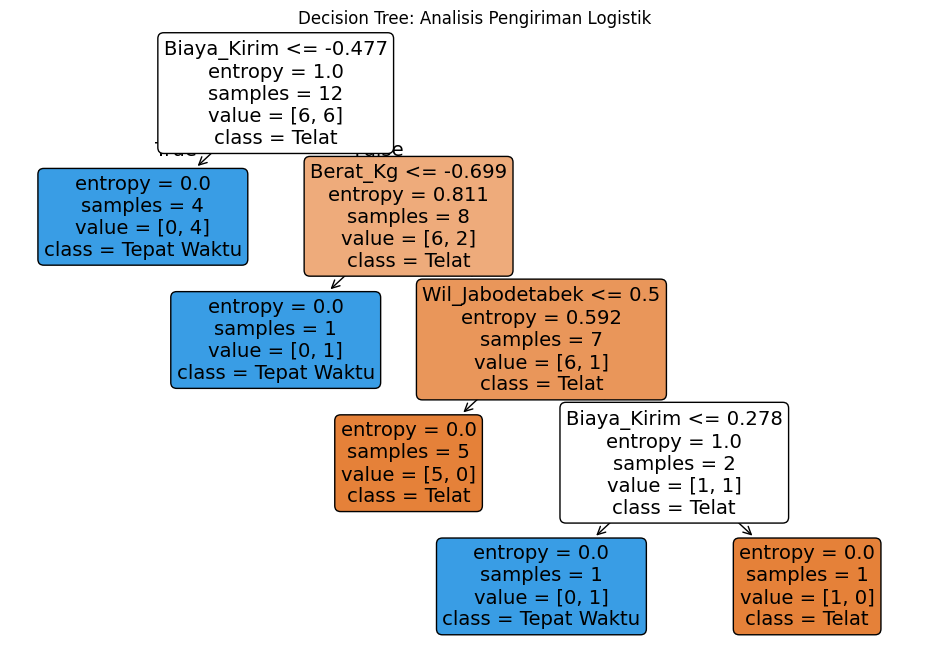

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score

# ==========================================
# 1. LOAD DATA DARI FILE CSV
# ==========================================
filename = 'Data_Logistik_Indo.csv'

try:
    # Membaca file CSV langsung ke variabel dataset
    dataset = pd.read_csv(filename)
    print(f"✅ Berhasil membaca file '{filename}'")
    print("\n[Preview Data 5 Baris Teratas]")
    print(dataset.head())
except FileNotFoundError:
    print(f"❌ ERROR: File '{filename}' tidak ditemukan!")
    print("Pastikan Anda sudah mengupload file CSV ke folder yang sama.")
    exit()

# Memisahkan Fitur (X) dan Target (y)
X = dataset.iloc[:, :-1].values # Ambil semua kolom KECUALI yang terakhir
y = dataset.iloc[:, -1].values  # Ambil kolom TERAKHIR saja (Target)

# ==========================================
# 2. PREPROCESSING (BERSIH-BERSIH DATA)
# ==========================================

# A. Handling Missing Values (Mengisi data kosong)
# Kolom ke-1 (Berat) dan ke-2 (Biaya) mungkin ada yang kosong (NaN)
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X[:, 1:3])
X[:, 1:3] = imputer.transform(X[:, 1:3])

# B. Encoding Data Kategorikal (Huruf -> Angka)
# Mengubah 'Wilayah' (Kolom 0) menjadi angka (One Hot Encoding)
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

# Mengubah Target 'Status' (Tepat Waktu/Telat) menjadi 0/1 (Label Encoding)
le = LabelEncoder()
y = le.fit_transform(y)

# C. Splitting Data (80% Latihan, 20% Ujian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# D. Feature Scaling (Menyamakan Skala)
# Penting karena Biaya (Puluhan Ribu) vs Berat (Satuan) beda jauh
sc = StandardScaler()
# Kita scale mulai kolom ke-3 (Karena kolom 0,1,2 adalah hasil kode Wilayah)
X_train[:, 3:] = sc.fit_transform(X_train[:, 3:])
X_test[:, 3:] = sc.transform(X_test[:, 3:])

# ==========================================
# 3. TRAINING MODEL (MEMBUAT POHON)
# ==========================================
# criterion='entropy' -> Agar logikanya sama persis dengan PPT (Information Gain)
classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

print("\n✅ Model Decision Tree berhasil dilatih!")

# ==========================================
# 4. EVALUASI & PREDIKSI
# ==========================================
y_pred = classifier.predict(X_test)

# Menghitung Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {akurasi*100:.2f}%")

# Menampilkan Tabel Perbandingan
print("\n[Tabel Hasil Prediksi Data Test]")
print(f"{'Kenyataan':<15} | {'Prediksi Mesin'}")
print("-" * 35)

for asli, pred in zip(y_test, y_pred):
    # Mengembalikan label 0/1 menjadi teks agar mudah dibaca
    lbl_asli = "Tepat Waktu" if asli == 1 else "Telat"
    lbl_pred = "Tepat Waktu" if pred == 1 else "Telat"

    # Memberi tanda jika prediksi salah
    status = "✅" if asli == pred else "❌ Meleset"

    print(f"{lbl_asli:<15} | {lbl_pred} {status}")

# ==========================================
# 5. VISUALISASI POHON KEPUTUSAN
# ==========================================
plt.figure(figsize=(12, 8))
# Nama fitur manual (sesuaikan urutan abjad OneHotEncoder: Jabodetabek, Jawa Barat, Luar Jawa)
nama_fitur = ['Wil_Jabodetabek', 'Wil_Jabar', 'Wil_LuarJawa', 'Berat_Kg', 'Biaya_Kirim']
nama_kelas = ['Telat', 'Tepat Waktu']

plot_tree(classifier,
          feature_names=nama_fitur,
          class_names=nama_kelas,
          filled=True,
          rounded=True)
plt.title("Decision Tree: Analisis Pengiriman Logistik")
plt.show()